# Composite breakdown
Keep the original surface-PV segregation below. Then choose one sample, inspect one reconstruction, and average **all available selected eddy-days** at each exact fitted depth. Days receive equal weight; this is deliberately separate from the larger population workflow.

Each whole profile is translated to its 0 m fitted centre. No radius scaling, slope rotation, vertical interpolation or matched-depth filtering is added. Deeper levels may have fewer contributing days; the support table shows this. ESP fields are idealised reconstructions, without land/bathymetric masking in this simple notebook. Coordinates remain relative model-grid x/y; velocity components retain the external ESP function's convention.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp
import seacofs_tilt_tools as tilt
pd.set_option('display.max_columns', 60)


In [2]:
DOMINANCE_FACTOR = 2.0
ELLIPSE_FRAC = 1.0
MIN_PLAN_DEPTH_m = 3000.0
MAX_TOPO_DEPTH_m = 3000.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)

In [3]:
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
surface = tilt.add_pv_gradient_terms(
    surface,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_cache=True, # change to true 
)
vertical = tilt.load_vert(paths)

In [4]:
surface['dom'] = 'mixed'
surface.loc[surface.topo_plan_ratio >=  np.log(DOMINANCE_FACTOR), 'dom'] = 'topo'
surface.loc[surface.topo_plan_ratio <= -np.log(DOMINANCE_FACTOR), 'dom'] = 'plan'

In [5]:
planetary = surface[(surface.dom=='plan')&(surface.h>=MIN_PLAN_DEPTH_m)].copy()
topographic = surface[(surface.dom=='topo')&(surface.h<=MAX_TOPO_DEPTH_m)].copy()

AE mean tilt dir 21, tilt dis 21 km
CE mean tilt dir 150, tilt dis 18 km


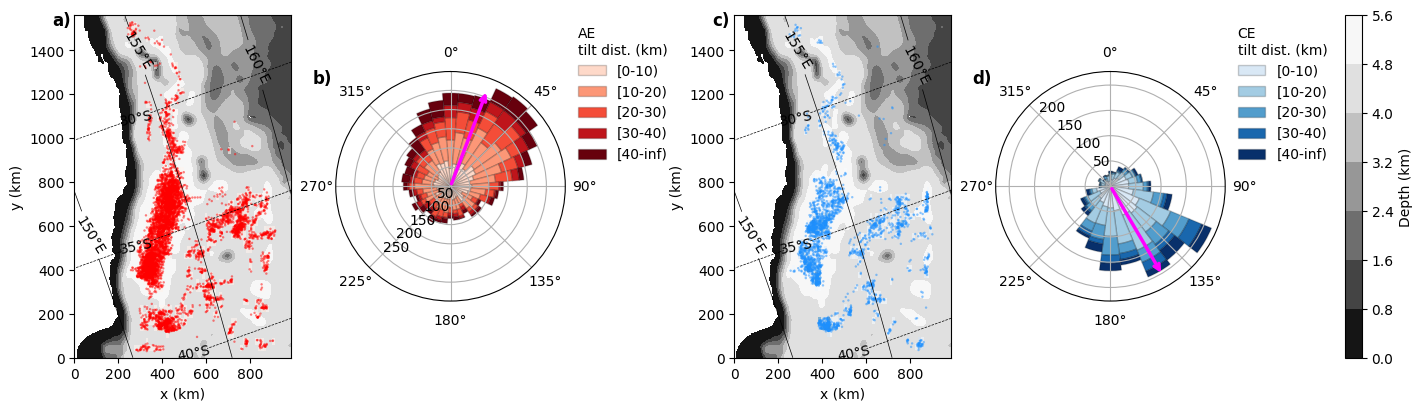

In [6]:
fig, axs = tilt.plot_tilt_summary(planetary.copy(), grid, mag_bins=[0, 10, 20, 30, 40, np.inf])

In [7]:
topographic

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,h,f,beta,dhdx,dhdy,zeta_mean,...,PV_grad_eddy_coherence,PV_grad_full_x,PV_grad_full_y,PV_grad_full_mean_local_mag,PV_grad_full_rms_local_mag,PV_grad_full_p90_local_mag,PV_grad_full_coherence,PV_grad_plan_mag,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,PV_grad_eddy_mag,PV_grad_eddy_theta,PV_grad_full_mag,PV_grad_full_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,dtheta_PV_grad_full,Ro,topo_plan_ratio,topo_plan_ratio_smooth,ellipse_frac,ellipse_inner_frac,ellipse_area_fraction,pv_averaging,pv_surface_method,dom
118,4,1493,CE,150.518728,-37.464100,92,42,244.562541,208.329230,-0.000050,-0.000021,1.734126,-0.362949,0.657316,37.677021,14.865502,1.837577,22.337952,36,1994-02-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.652775,231.141407,S2,2859.392211,-0.000089,1.842881e-11,0.093953,-0.015892,-0.000040,...,0.469340,4.490278e-12,-1.083007e-12,4.648605e-12,8.328588e-12,1.425159e-11,0.993639,9.195990e-15,0.0,4.851263e-12,102.628493,4.849261e-12,102.522468,2.456622e-13,262.614571,4.619036e-12,103.560145,128.618939,128.512913,128.858593,127.581262,0.564797,6.268227,6.268227,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
119,4,1494,CE,150.430296,-37.456043,89,42,236.888864,206.512995,-0.000052,-0.000021,1.618557,-0.563463,0.878391,37.197425,13.298593,1.829614,22.925006,36,1994-02-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.981880,243.521114,S2,2079.860571,-0.000089,1.843033e-11,0.092980,-0.016552,-0.000041,...,0.627347,1.343765e-11,-3.668127e-12,1.401188e-11,2.284990e-11,4.452289e-11,0.994107,2.157437e-14,0.0,1.470887e-11,104.181178,1.470360e-11,104.099671,8.274811e-13,264.021250,1.392931e-11,105.268262,139.421443,139.339936,116.478886,138.252852,0.584148,6.524700,6.278428,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
120,4,1495,CE,150.354841,-37.452925,87,42,230.474313,204.573533,-0.000043,-0.000017,1.223692,-0.591723,1.274639,36.717828,11.731684,1.674290,21.223970,36,1994-02-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,S2,1498.939238,-0.000089,1.843128e-11,0.081873,-0.014957,-0.000035,...,0.603016,2.058836e-11,-5.789549e-12,2.155739e-11,3.030244e-11,5.779551e-11,0.992091,4.242998e-14,0.0,2.261307e-11,104.732420,2.260232e-11,104.628398,1.283872e-12,266.366850,2.138689e-11,105.706251,NaN,NaN,NaN,NaN,0.490398,6.278428,6.278428,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
121,4,1496,CE,150.324102,-37.358688,84,43,224.580419,213.431794,-0.000018,-0.000007,0.983503,-0.586885,1.471077,36.717828,11.731684,1.774191,18.715128,36,1994-02-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,S2,1282.549535,-0.000088,1.845422e-11,0.071745,-0.010367,-0.000014,...,0.538611,2.487503e-11,-5.639087e-12,2.572732e-11,3.588503e-11,6.168374e-11,0.991405,6.489363e-14,0.0,2.616343e-11,102.412953,2.614956e-11,102.274089,6.815114e-13,263.259440,2.550620e-11,102.772881,NaN,NaN,NaN,NaN,0.199662,5.999369,6.225974,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
122,4,1497,CE,150.404345,-37.335453,87,44,230.473201,218.252867,-0.000044,-0.000019,0.776010,-0.434028,1.564231,36.717828,11.731684,1.734425,19.287379,36,1994-02-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,S2,1745.194533,-0.000088,1.845861e-11,0.078084,-0.010573,-0.000035,...,0.576708,2.144715e-11,-4.357523e-12,2.210503e-11,3.343689e-11,6.311766e-11,0.990061,4.553672e-14,0.0,2.302863e-11,100.371933,2.302047e-11,100.260449,1.232295e-12,257.960130,2.188534e-11,101.484739,NaN,NaN,NaN,NaN,0.492633,6.225974,NaN,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127320,2979,10627,CE,160.329928,-29.820875,250,268,861.813328,1322.292405,-0.000012,-0.000005,1.115546,0.372644,1.022075,69.388241,12.9

## Choose the sample

In [8]:
# Change only this line to try another of your segregated samples.
sample = planetary.loc[planetary.Cyc.eq('CE')].copy()
REFERENCE_DEPTH_M = 0.0
MAX_COMPOSITE_DEPTH_M = None  # None uses every available fitted depth
print(f'Selected {len(sample)} eddy-days from {sample.Eddy.nunique()} eddies')


Selected 2250 eddy-days from 430 eddies


## Reconstruction helpers

In [9]:
def valid_profiles(vertical):
    needed = ['Eddy', 'Day', 'Depth', 'xc', 'yc', 'Rc', 'Omega', 'q11', 'q12', 'q22']
    valid = vertical.loc[np.isfinite(vertical[needed].to_numpy(float)).all(axis=1)].copy()
    valid = valid.loc[(valid.Depth >= 0) & (valid.Rc > 0)
                      & (valid.q11 > 0) & (valid.q22 > 0)
                      & (valid.q11 * valid.q22 - valid.q12**2 > 0)]
    if valid.duplicated(['Eddy', 'Day', 'Depth']).any():
        raise ValueError('Duplicate Eddy-Day-Depth rows; resolve these before averaging.')
    return valid


def choose_case(surface, vertical, eddy_id=None, day=None, reference_depth=0.):
    # Match BOTH keys to the chosen sample, before choosing an example.
    keys = surface[['Eddy', 'Day']]
    if keys.duplicated().any():
        raise ValueError('Duplicate Eddy-Day rows in the selected sample.')
    valid = valid_profiles(vertical).merge(keys, on=['Eddy', 'Day'], validate='many_to_one')
    if eddy_id is not None:
        valid = valid.loc[valid.Eddy.eq(eddy_id)]
    if day is not None:
        valid = valid.loc[valid.Day.eq(day)]
    references = valid.loc[valid.Depth.eq(reference_depth), ['Eddy', 'Day']]
    if references.empty:
        raise ValueError('No selected eddy-day has a valid profile at the reference depth.')
    # Deterministic first available day (not the deepest or most tilted example).
    choice = references.sort_values(['Eddy', 'Day']).iloc[0]
    profile = valid.loc[valid.Eddy.eq(choice.Eddy) & valid.Day.eq(choice.Day)].sort_values('Depth').copy()
    row = surface.loc[surface.Eddy.eq(choice.Eddy) & surface.Day.eq(choice.Day)].iloc[0]
    return row, profile.reset_index(drop=True)


def recenter(profile, reference_depth=0.):
    profile = profile.copy()
    reference = profile.loc[profile.Depth.eq(reference_depth)]
    if len(reference) != 1:
        raise ValueError('Each day needs exactly one row at the common reference depth.')
    profile['xc'] -= float(reference.xc.iloc[0])
    profile['yc'] -= float(reference.yc.iloc[0])
    return profile


def reconstruct(profile, X, Y):
    # Input positions are kilometres; ESP expects metres.
    U, V = [], []
    for row in profile.itertuples(index=False):
        Q = np.array([[row.q11, row.q12], [row.q12, row.q22]])
        u, v = esp.model_uv_at_xy(X*1e3, Y*1e3, row.xc*1e3, row.yc*1e3,
                                  Q, row.Omega, row.Rc*1e3)
        U.append(u); V.append(v)
    if not U:
        raise ValueError('No fitted levels to reconstruct.')
    return np.stack(U, axis=-1), np.stack(V, axis=-1)


def composite_days(sample, vertical, X, Y, reference_depth=0., max_depth=None):
    keys = sample[['Eddy', 'Day']].copy()
    if keys.duplicated().any():
        raise ValueError('Duplicate Eddy-Day rows in sample would double-count days.')
    valid = valid_profiles(vertical).merge(keys, on=['Eddy', 'Day'], validate='many_to_one')
    if max_depth is not None:
        valid = valid.loc[valid.Depth.le(max_depth)]
    ref_keys = valid.loc[valid.Depth.eq(reference_depth), ['Eddy', 'Day']]
    usable = valid.merge(ref_keys, on=['Eddy', 'Day'], validate='many_to_one')
    if usable.empty:
        raise ValueError('No selected days have a valid profile at the reference depth.')
    depths = np.sort(usable.Depth.unique())
    shape = (*X.shape, len(depths))  # y, x, exact fitted depth
    u_tot, v_tot = np.zeros(shape), np.zeros(shape)
    counts = np.zeros(shape, dtype=np.int64)
    depth_days = np.zeros(len(depths), dtype=np.int64)
    included = []
    for (eddy, day), profile in usable.groupby(['Eddy', 'Day'], sort=True):
        profile = recenter(profile.sort_values('Depth'), reference_depth)
        u, v = reconstruct(profile, X, Y)
        contributed = False
        for j, depth in enumerate(profile.Depth):
            k = np.searchsorted(depths, depth)
            finite = np.isfinite(u[..., j]) & np.isfinite(v[..., j])
            if not finite.any():
                continue
            u_tot[..., k] += np.where(finite, u[..., j], 0.)
            v_tot[..., k] += np.where(finite, v[..., j], 0.)
            counts[..., k] += finite
            depth_days[k] += 1
            contributed = True
        if contributed:
            included.append((eddy, day))
        if len(included) and len(included) % 100 == 0:
            print(f'Reconstructed {len(included)} eddy-days', flush=True)
    if not included:
        raise ValueError('ESP returned no finite velocity for the selected days.')
    u_ave = np.divide(u_tot, counts, out=np.full(shape, np.nan), where=counts > 0)
    v_ave = np.divide(v_tot, counts, out=np.full(shape, np.nan), where=counts > 0)
    included = pd.DataFrame(included, columns=['Eddy', 'Day'])
    audit = keys.merge(included.assign(included=True), on=['Eddy', 'Day'], how='left', validate='one_to_one')
    audit['included'] = audit.included.eq(True)
    ref_index = pd.MultiIndex.from_frame(ref_keys)
    has_reference = pd.MultiIndex.from_frame(audit[['Eddy', 'Day']]).isin(ref_index)
    audit['status'] = np.where(audit.included, 'included',
                             np.where(has_reference, 'no finite ESP velocity',
                                      'no valid profile at reference depth'))
    support = pd.DataFrame({'Depth': depths, 'eddy_days': depth_days,
                            'min_cell_days': counts.min(axis=(0, 1)),
                            'max_cell_days': counts.max(axis=(0, 1))})
    return u_ave, v_ave, depths, counts, support, audit


## Inspect one selected eddy-day

In [10]:
WIDTH_KM = 400
RES_KM = 10
a = np.arange(-WIDTH_KM/2, WIDTH_KM/2 + RES_KM/2, RES_KM)
X, Y = np.meshgrid(a, a)

row, profile = choose_case(sample, vertical, reference_depth=REFERENCE_DEPTH_M)
profile = recenter(profile, REFERENCE_DEPTH_M)
u_esp, v_esp = reconstruct(profile, X, Y)
print(f'Example: Eddy {int(row.Eddy)}, Day {int(row.Day)}; {len(profile)} fitted levels')


Example: Eddy 5, Day 1473; 3 fitted levels


(np.float64(-200.0), np.float64(200.0), np.float64(-200.0), np.float64(200.0))

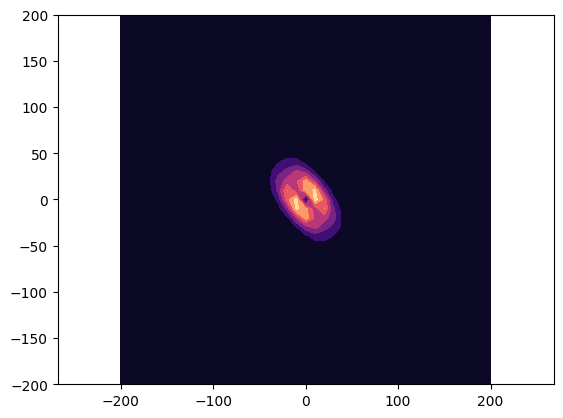

In [11]:
plt.contourf(X, Y, np.hypot(u_esp[:,:,0], v_esp[:,:,0]), cmap='magma')
plt.axis('equal')

## Composite all available selected eddy-days
A missing profile is skipped. Every exact depth has its own finite-value denominator; missing depths never contribute zero velocity.

In [12]:
u_ave, v_ave, depths, counts, support, composite_audit = composite_days(
    sample, vertical, X, Y, reference_depth=REFERENCE_DEPTH_M,
    max_depth=MAX_COMPOSITE_DEPTH_M,
)
cnt = int(composite_audit.included.sum())
print(f'Included {cnt}/{len(sample)} selected eddy-days')
display(composite_audit.status.value_counts().rename('eddy_days'))
with pd.option_context('display.max_rows', None):
    display(support)


Reconstructed 100 eddy-days
Reconstructed 200 eddy-days
Reconstructed 300 eddy-days
Reconstructed 400 eddy-days
Reconstructed 500 eddy-days
Reconstructed 600 eddy-days
Reconstructed 700 eddy-days
Reconstructed 800 eddy-days
Reconstructed 900 eddy-days
Reconstructed 1000 eddy-days
Reconstructed 1100 eddy-days
Reconstructed 1200 eddy-days
Reconstructed 1300 eddy-days
Reconstructed 1400 eddy-days
Reconstructed 1500 eddy-days
Reconstructed 1600 eddy-days
Reconstructed 1700 eddy-days
Reconstructed 1800 eddy-days
Reconstructed 1900 eddy-days
Reconstructed 2000 eddy-days
Reconstructed 2100 eddy-days
Included 2131/2250 selected eddy-days


status
included                               2131
no valid profile at reference depth     119
Name: eddy_days, dtype: int64

,Depth,eddy_days,min_cell_days,max_cell_days
0,0.000000,2131,2131,2131
1,5.879627,2131,2131,2131
2,10.725783,2131,2131,2131
3,16.383097,2114,2114,2114
4,22.925581,2109,2109,2109
5,30.444118,2105,2105,2105
6,39.052712,2101,2101,2101
7,48.897638,2096,2096,2096
8,60.170639,2091,2091,2091
9,73.127842,2087,2087,2087


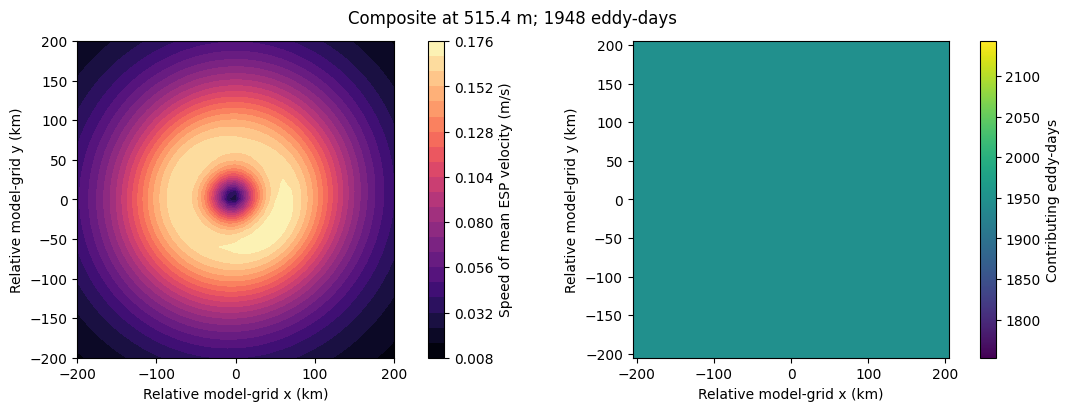

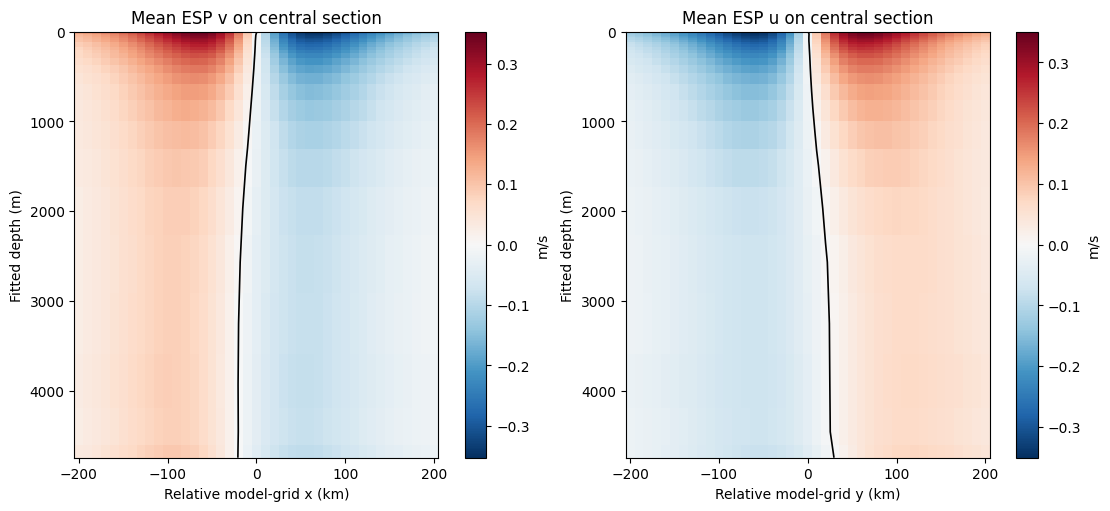

In [14]:
# Plot at one actual fitted depth; no vertical interpolation.
PLOT_DEPTH_M = 500.0
k = int(np.argmin(np.abs(depths - PLOT_DEPTH_M)))
fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
im = axs[0].contourf(X, Y, np.hypot(u_ave[..., k], v_ave[..., k]), levels=20, cmap='magma')
fig.colorbar(im, ax=axs[0], label='Speed of mean ESP velocity (m/s)')
im = axs[1].pcolormesh(X, Y, counts[..., k], shading='auto')
fig.colorbar(im, ax=axs[1], label='Contributing eddy-days')
for ax in axs:
    ax.set(xlabel='Relative model-grid x (km)', ylabel='Relative model-grid y (km)', aspect='equal')
fig.suptitle(f'Composite at {depths[k]:.1f} m; {support.eddy_days.iloc[k]} eddy-days')
plt.show()

# y=0 section: v across x; x=0 section: u across y.
mid_y = int(np.argmin(abs(Y[:, 0])))
mid_x = int(np.argmin(abs(X[0, :])))

fig, axs = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
sections = [v_ave[mid_y, :, :].T, u_ave[:, mid_x, :].T]

for ax, section, coord, label, component in zip(
    axs, sections, [X[0, :], Y[:, 0]], ['x', 'y'], ['v', 'u']
):
    finite = section[np.isfinite(section)]
    limit = max(float(np.max(abs(finite))) if len(finite) else 0., 1e-12)

    im = ax.pcolormesh(coord, depths, section, shading='auto',
                       cmap='RdBu_r', vmin=-limit, vmax=limit)
    ax.contour(coord, depths, section, levels=[0], colors='k', linewidths=1.2)

    if len(depths) > 1:
        ax.set_ylim(depths[-1], depths[0])

    ax.set(xlabel=f'Relative model-grid {label} (km)', ylabel='Fitted depth (m)',
           title=f'Mean ESP {component} on central section')
    fig.colorbar(im, ax=ax, label='m/s')

plt.show()
